<a href="https://colab.research.google.com/github/Fahrisetiadarma/DataAnalytics/blob/main/A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DS/HW5/1.csv')

In [ ]:
df

,period,cohort_date,variant,user_id,country,platform,traffic_source,device_model,age,sessions_7d,time_to_first_action_min,trial_start,paid_subscriber,revenue_30d
0,during,2025-07-05,B,APP201334,ID,android,organic,low_end,54,4,6.1,0,0,444.616527
1,during,2025-07-04,A,APP201596,ID,android,organic,low_end,24,2,6.5,0,0,424.835708
2,during,2025-07-06,A,APP200545,TH,android,organic,mid_range,41,4,7.3,0,0,393.086785
3,during,2025-07-07,B,APP203155,MY,android,organic,mid_range,40,1,2.3,0,0,502.190971
4,during,2025-07-04,A,APP202354,ID,android,paid,mid_range,49,6,2.4,1,0,432.384427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,during,2025-07-06,A,APP203295,ID,android,organic,low_end,21,3,6.1,1,1,451.623263
501,during,2025-07-10,B,APP203577,TH,android,organic,flagship,22,8,3.8,1,0,447.467872
502,during,2025-07-09,A,APP202962,ID,android,social,mid_range,34,5,6.6,1,1,324.031502
503,during,2025-07-11,A,APP207633,ID,ios,paid,low_end,48,4,3.4,0,0,375.788296


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   period                    505 non-null    object 
 1   cohort_date               505 non-null    object 
 2   variant                   505 non-null    object 
 3   user_id                   505 non-null    object 
 4   country                   505 non-null    object 
 5   platform                  505 non-null    object 
 6   traffic_source            505 non-null    object 
 7   device_model              505 non-null    object 
 8   age                       505 non-null    int64  
 9   sessions_7d               505 non-null    int64  
 10  time_to_first_action_min  505 non-null    float64
 11  trial_start               505 non-null    int64  
 12  paid_subscriber           505 non-null    int64  
 13  revenue_30d               505 non-null    float64
dtypes: float64

In [ ]:
df.variant.value_counts()

,count
variant,
A,257
B,248


# Menyamakan variance

In [ ]:
X = df.drop('variant', axis=1)
y = df['variant']

X = X.drop(['user_id', 'cohort_date'], axis=1)
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [ ]:
df_balanced = pd.concat([pd.DataFrame(X_res), pd.Series(y_res, name='variant')], axis=1)
print(df_balanced['variant'].value_counts())

variant
B    257
A    257
Name: count, dtype: int64


In [ ]:
df_during=df_balanced.copy()
df_during.shape

(514, 18)

# Hypothesis Testing

In [ ]:
revenue_30d_a= df_during[df_during['variant']=='A']['revenue_30d']
revenue_30d_b= df_during[df_during['variant']=='B']['revenue_30d']

In [ ]:
stat_A, p_A = stats.shapiro(revenue_30d_a)
stat_B, p_B = stats.shapiro(revenue_30d_b)

print(f"Shapiro-Wilk test for Variant A: Statistic = {stat_A:.4f}, p-value = {p_A:.4f}")
print(f"Shapiro-Wilk test for Variant B: Statistic = {stat_B:.4f}, p-value = {p_B:.4f}")

alpha = 0.05

print("\nVariant A")
if p_A > alpha:
    print("Data appears normal")
else:
    print("No evidence to say the data is normal")

print("\nVariant B")
if p_B > alpha:
    print("Data appears normal")
else:
    print("No evidence to say the data is normal")

Shapiro-Wilk test for Variant A: Statistic = 0.9919, p-value = 0.1668
Shapiro-Wilk test for Variant B: Statistic = 0.9967, p-value = 0.8805

Variant A
Data appears normal

Variant B
Data appears normal


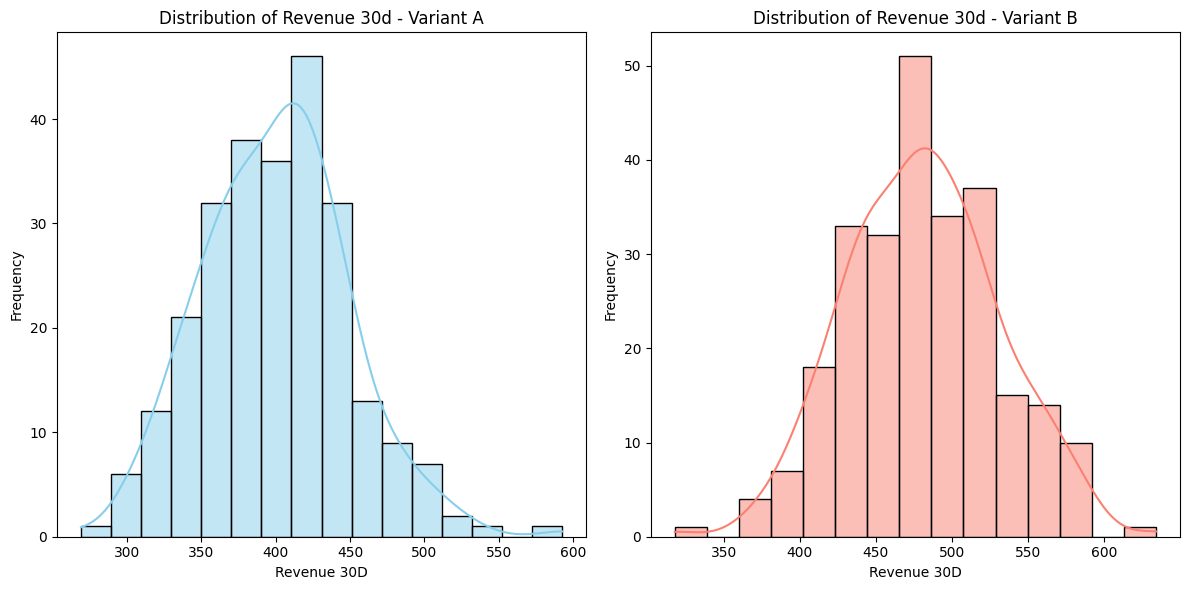

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(revenue_30d_a, kde=True, color='skyblue')
plt.title("Distribution of Revenue 30d - Variant A")
plt.xlabel("Revenue 30D")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(revenue_30d_b, kde=True, color='salmon')
plt.title("Distribution of Revenue 30d - Variant B")
plt.xlabel("Revenue 30D")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Homogenity of Variance

In [ ]:
stat, p_value = stats.levene(revenue_30d_a, revenue_30d_b)

print("Levene's Test for Equality of Variances")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Varians berbeda secara signifikan (tolak H0).")
else:
    print("Tidak ada bukti varians berbeda (gagal menolak H0).")


Levene's Test for Equality of Variances
Statistic: 0.1309
P-value: 0.7176
Tidak ada bukti varians berbeda (gagal menolak H0).


# Ttest

In [ ]:
t_stat, p_value = stats.ttest_ind(revenue_30d_b,revenue_30d_a,equal_var=True)

print("Independent Samples t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Variant B memiliki rata-rata revenue_30d yang lebih tinggi secara signifikan (tolak H0).")
else:
    print("Tidak ada bukti bahwa Variant B lebih tinggi dari Variant A (gagal menolak H0).")


Independent Samples t-test
T-statistic: 18.4426
P-value: 0.0000
Variant B memiliki rata-rata revenue_30d yang lebih tinggi secara signifikan (tolak H0).
